# Criação do índice de sentimentos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from nltk.corpus import stopwords
from nltk import ngrams
from nltk.tokenize import word_tokenize
from collections import Counter
import spacy
nlp = spacy.load('pt_core_news_sm')

In [2]:
# Carregando dados
df = pd.read_csv('dados/folhamercado_tweets.csv', usecols=['date', 'user', 'tweet'])

df.head()

,date,user,tweet
0,2011-01-01,folha_mercado,Lojas de shoppings centers estão proibidos de ...
1,2011-01-01,folha_mercado,"VIDEO: Governo vai ter que ""se esforçar"" para ..."
2,2011-01-01,folha_mercado,Veja as manchetes dos principais jornais deste...
3,2011-01-01,folha_mercado,"De férias, Obama diz que sua meta para 2011 é ..."
4,2011-01-01,folha_mercado,Governo prorroga até 2035 encargo na conta de ...


In [15]:
# Pré-processamento
import re
import string

df['date'] = pd.to_datetime(df['date'])

df['tweet'] = df['tweet'].apply(lambda x: re.sub("http\S+", "", x))
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'#\w+', '', x))

stop_words = set(stopwords.words('portuguese'))
stop_words.update(['em', 'um', 'uma', 'a', 'as', 'o', 'os', 'de', 'do', 'da', 'dos', 'das', 'e', 'que', 'com', 
                   'para', 'por', 'no', 'na', 'nos', 'nas', 'em', 'este', 'esta', 'esse', 'essa', 'neste', 'nesta'])

df['tweet_clean'] = df['tweet'].str.lower()
df['tweet_clean'] = df['tweet_clean'].str.replace('r$', '')
df['tweet_clean'] = df['tweet_clean'].str.translate(str.maketrans('', '', string.punctuation))
df['tweet_clean'] = df['tweet_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

df.head()

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\luans\AppData\Local\Temp\ipykernel_20336\2293000921.py:7: SyntaxWarning: invalid escape sequence '\S'
  df['tweet'] = df['tweet'].apply(lambda x: re.sub("http\S+", "", x))


,date,user,tweet,tweet_clean,tweet_lemma
0,2011-01-01,folha_mercado,Lojas de shoppings centers estão proibidos de ...,lojas shoppings centers proibidos abrir hoje,loja Shoppings centers proibir abrir hoje
1,2011-01-01,folha_mercado,"VIDEO: Governo vai ter que ""se esforçar"" para ...",video governo vai ter esforçar combater inflaç...,video governo ir ter esforçar combater inflaçã...
2,2011-01-01,folha_mercado,Veja as manchetes dos principais jornais deste...,veja manchetes principais jornais deste sábado,ver manchete principal jornal de este sábado
3,2011-01-01,folha_mercado,"De férias, Obama diz que sua meta para 2011 é ...",férias obama diz meta 2011 recuperar economia,férias obama dizer meta 2011 recuperar economia
4,2011-01-01,folha_mercado,Governo prorroga até 2035 encargo na conta de ...,governo prorroga 2035 encargo conta luz,governo prorrogar 2035 encargo contar luz


In [16]:
# Lemmatization
lemma_docs = nlp.pipe(df['tweet_clean'])

df['tweet_lemma'] = [' '.join([token.lemma_ for token in doc]) for doc in lemma_docs]

In [5]:
df.to_csv('dados/fm_tweets_preprocessed.csv', index=False)

## Análise de Dados

In [45]:
# extraindo n-grams
from functions import get_ngrams
from collections import Counter

df_range = df[(df['date'] >= '2013-01-01') & (df['date'] <= '2019-12-31')]

bigrams = get_ngrams(df_range['tweet_clean'], 2)
trigrams = get_ngrams(df_range['tweet_clean'], 3)

freq_bigram = Counter(bigrams)
freq_trigram = Counter(trigrams)

print('Bi-grans mais comuns:')
for n, freq in enumerate(freq_bigram.most_common(5)):
    print(f'Bi-gram {n+1}: {freq[0]} - Frequência: {freq[1]}')

print('=' * 20)

print('Tri-grans mais comuns:')
for n, freq in enumerate(freq_trigram.most_common(5)):
    print(f'Tri-gram {n+1}: {freq[0]} - Frequência: {freq[1]}')

Bi-grans mais comuns:
Bi-gram 1: ('reforma', 'previdência') - Frequência: 606
Bi-gram 2: ('diz', 'presidente') - Frequência: 399
Bi-gram 3: ('dólar', 'cai') - Frequência: 353
Bi-gram 4: ('banco', 'central') - Frequência: 350
Bi-gram 5: ('dólar', 'sobe') - Frequência: 337
Tri-grans mais comuns:
Tri-gram 1: ('bolsas', 'europa', 'fecham') - Frequência: 51
Tri-gram 2: ('new', 'york', 'times') - Frequência: 46
Tri-gram 3: ('taxa', 'básica', 'juros') - Frequência: 45
Tri-gram 4: ('dólar', 'fecha', 'alta') - Frequência: 44
Tri-gram 5: ('invisto', 'veja', 'investimento') - Frequência: 39


## Aplicação do modelo

In [46]:
# Carregando modelo

import joblib
model = joblib.load('modelos/naive_bayes_sentiment_analysis_ptbr.pkl')

x1 = df_range['tweet_lemma']
y1_pred = model.predict(x1)

x2 = df_range['tweet_clean']
y2_pred = model.predict(x2)

df_range['sentiment'] = y1_pred
df_range['sentiment_2'] = y2_pred
df_range.to_csv('dados/fm_tweets_sentiment.csv', index=False)

C:\Users\luans\AppData\Local\Temp\ipykernel_20336\1345254627.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_range['sentiment'] = y1_pred
C:\Users\luans\AppData\Local\Temp\ipykernel_20336\1345254627.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_range['sentiment_2'] = y2_pred


In [47]:
for col in ['sentiment', 'sentiment_2']:
    print(f'Análise de Sentimento - {col}')
    print(df_range[col].value_counts())
    print('=' * 20)

Análise de Sentimento - sentiment
sentiment
neutral     35798
positive     8245
negative     6720
Name: count, dtype: int64
Análise de Sentimento - sentiment_2
sentiment_2
neutral     38464
positive     8025
negative     4274
Name: count, dtype: int64


<Axes: title={'center': 'Índice de Sentimento ao Longo do Tempo'}, xlabel='date'>

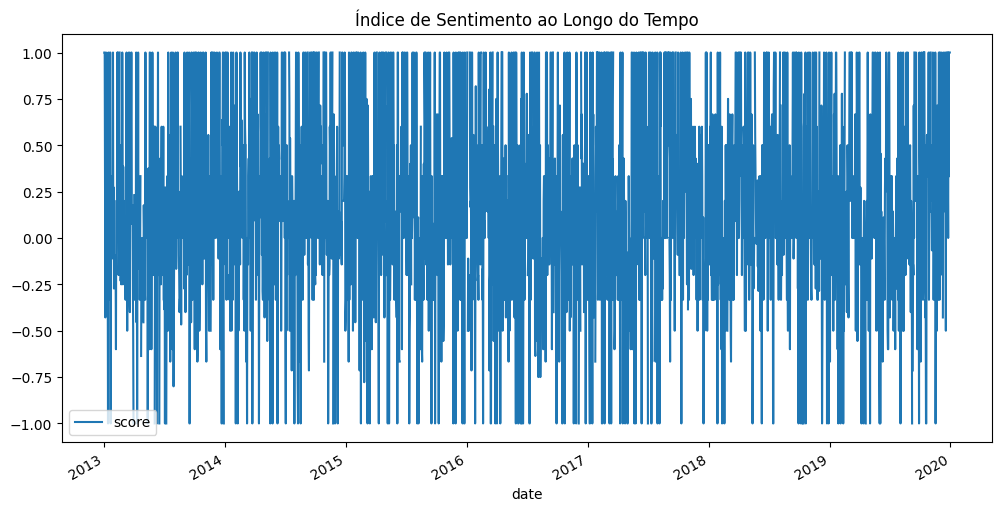

In [49]:
df_pivot = df_range.groupby(['date', 'sentiment']).size().unstack(fill_value=0)
df_pivot['score'] = (df_pivot['positive'] - df_pivot['negative']) / (df_pivot['positive'] + df_pivot['negative'])

df_pivot.plot(y='score', kind='line', figsize=(12, 6), title='Índice de Sentimento ao Longo do Tempo')

<Axes: title={'center': 'Índice de Sentimento Mensal'}, xlabel='date'>

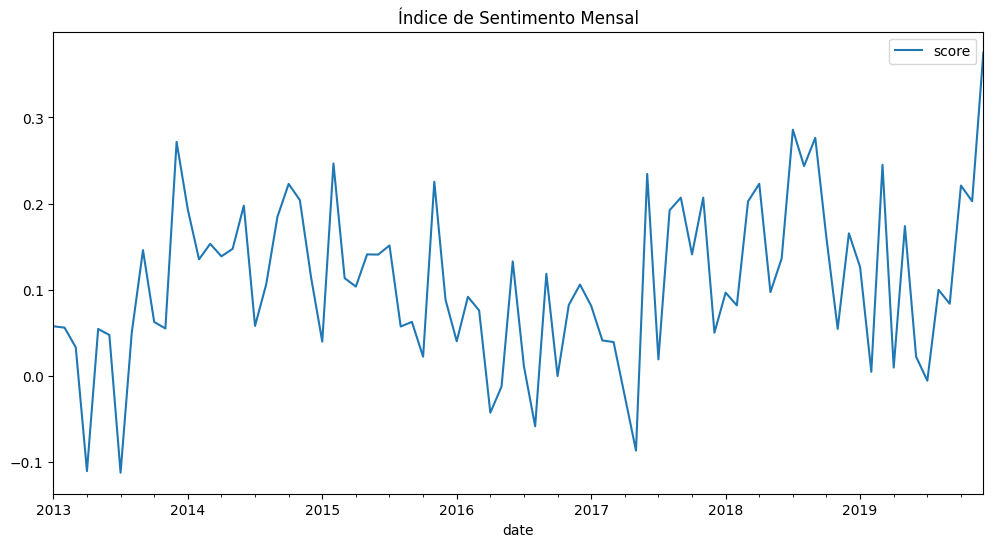

In [50]:
df_monthly = df_range.groupby([df_range['date'].dt.to_period('M'), 'sentiment']).size().unstack(fill_value=0)
df_monthly['score'] = (df_monthly['positive'] - df_monthly['negative']) / (df_monthly['positive'] + df_monthly['negative'])

df_monthly.plot(y='score', kind='line', figsize=(12, 6), title='Índice de Sentimento Mensal')

In [51]:
df_monthly['score'].describe()

count    84.000000
mean      0.108327
std       0.094195
min      -0.112069
25%       0.049614
50%       0.101913
75%       0.176613
max       0.375000
Name: score, dtype: float64

<Axes: title={'center': 'Distribuição do Índice de Sentimento Mensal'}, ylabel='Frequency'>

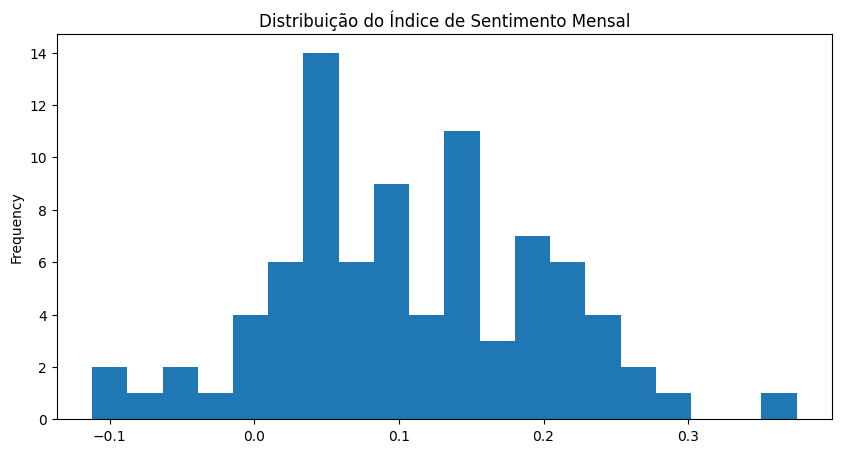

In [52]:
df_monthly['score'].plot(kind='hist', bins=20, figsize=(10, 5), title='Distribuição do Índice de Sentimento Mensal')

In [53]:
df_monthly.to_csv('dados/df_monthly_sentiment.csv')

## Puxando dados do IBOVESPA

[*********************100%***********************]  1 of 1 completed


<Axes: title={'center': 'Índice Bovespa (2013-2019)'}, xlabel='date'>

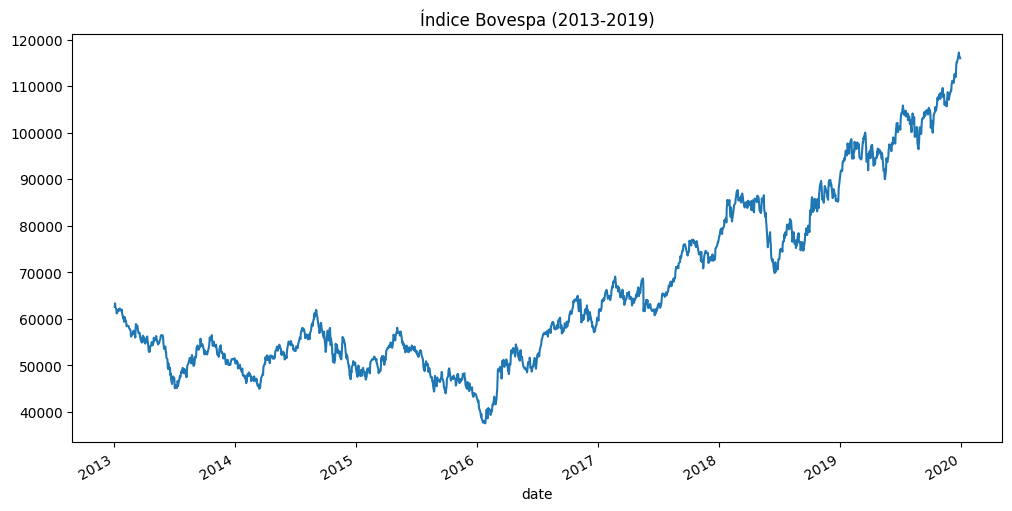

In [3]:
import yfinance as yf

ibov = yf.download('^BVSP', start='2013-01-01', end='2019-12-31')['Close'].reset_index()
ibov.columns = ['date', 'close']
ibov.plot(x='date', y='close', figsize=(12, 6), title='Índice Bovespa (2013-2019)', legend=False)

<Axes: title={'center': 'Variação Percentual do Índice Bovespa (2013-2019)'}, xlabel='date'>

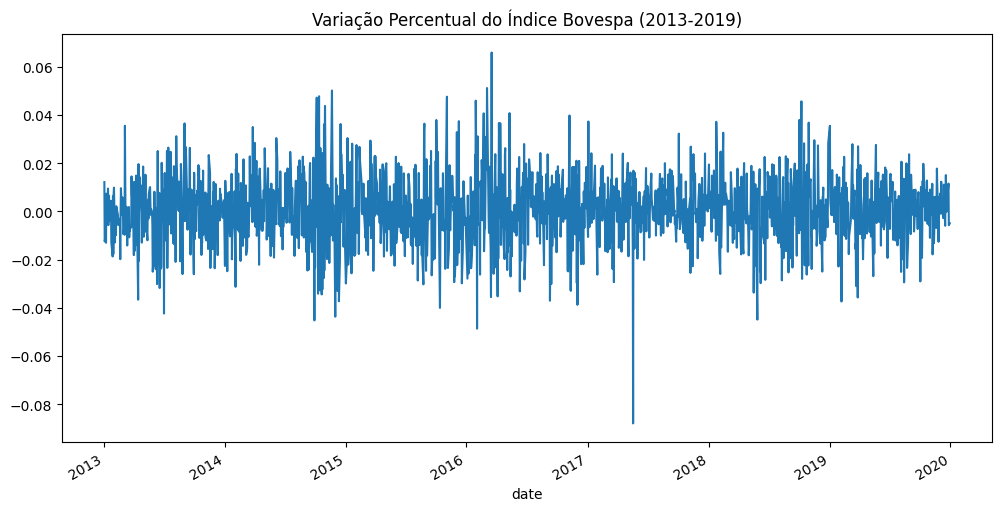

In [4]:
ibov['var_close'] = ibov['close'].pct_change()
ibov.plot(x='date', y='var_close', figsize=(12, 6), title='Variação Percentual do Índice Bovespa (2013-2019)', legend=False)

C:\Users\luans\AppData\Local\Temp\ipykernel_12260\2141409618.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_monthly = ibov.set_index('date').resample('M').last().reset_index()


<Axes: title={'center': 'Variação Percentual Mensal do Índice Bovespa (2013-2019)'}, xlabel='date'>

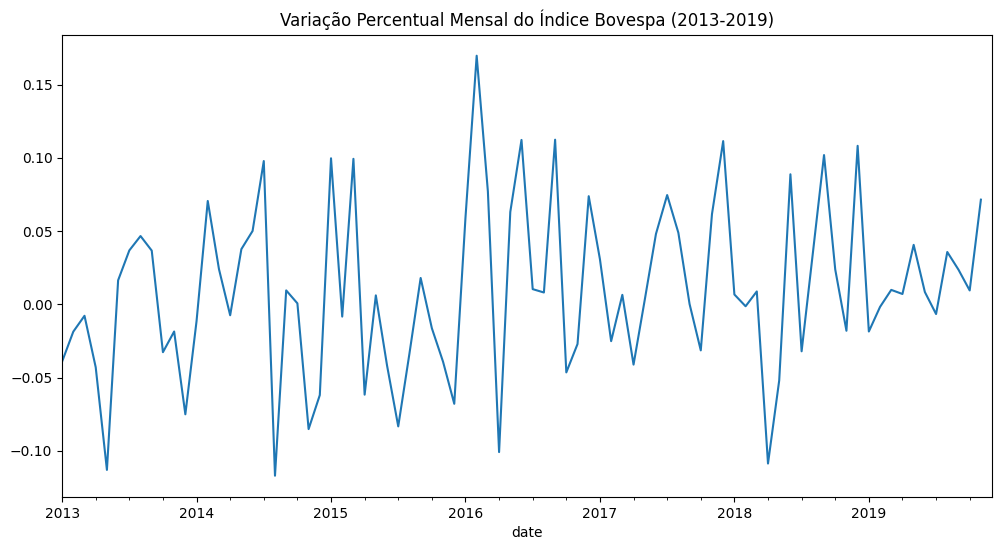

In [15]:
ibov_monthly = ibov.set_index('date').resample('M').last().reset_index()
ibov_monthly['var_close'] = ibov_monthly['close'].pct_change()
ibov_monthly['var_close'] = ibov_monthly['var_close'].shift(-1)
ibov_monthly.plot(x='date', y='var_close', figsize=(12, 6), title='Variação Percentual Mensal do Índice Bovespa (2013-2019)', legend=False)

<Axes: title={'center': 'Distribuição da Variação Percentual Mensal do Índice Bovespa'}, ylabel='Frequency'>

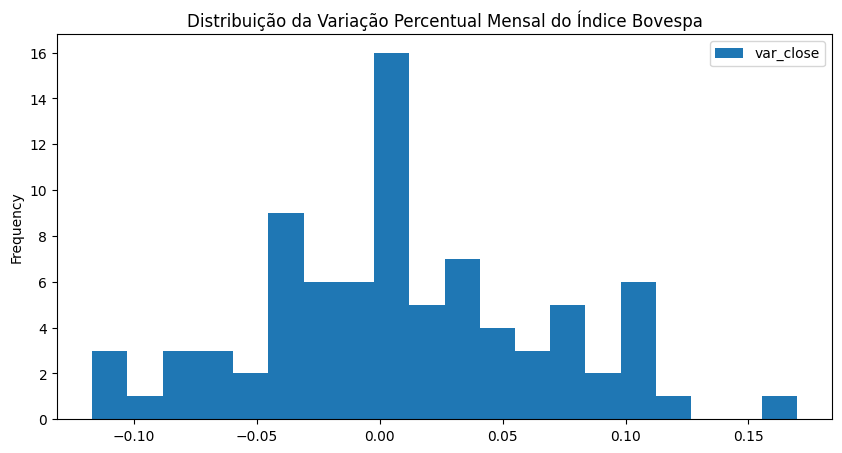

In [19]:
ibov_monthly.plot(kind='hist', y='var_close', bins=20, figsize=(10, 5), title='Distribuição da Variação Percentual Mensal do Índice Bovespa')

In [16]:
df_monthly_sentiment = pd.read_csv('dados/df_monthly_sentiment.csv')
df_monthly_sentiment['date'] = pd.to_datetime(df_monthly_sentiment['date'])
df_monthly_sentiment['var_ibov'] = ibov_monthly['var_close'].values
df_monthly_sentiment.head()

,date,negative,neutral,positive,score,var_ibov
0,2013-01-01,106,584,119,0.057778,-0.039106
1,2013-02-01,84,529,94,0.056180,-0.018668
2,2013-03-01,116,542,124,0.033333,-0.007844
3,2013-04-01,141,541,113,-0.110236,-0.042998
4,2013-05-01,121,516,135,0.054688,-0.113053


<Axes: title={'center': 'Índice de Sentimento vs Variação do Ibovespa'}, xlabel='date'>

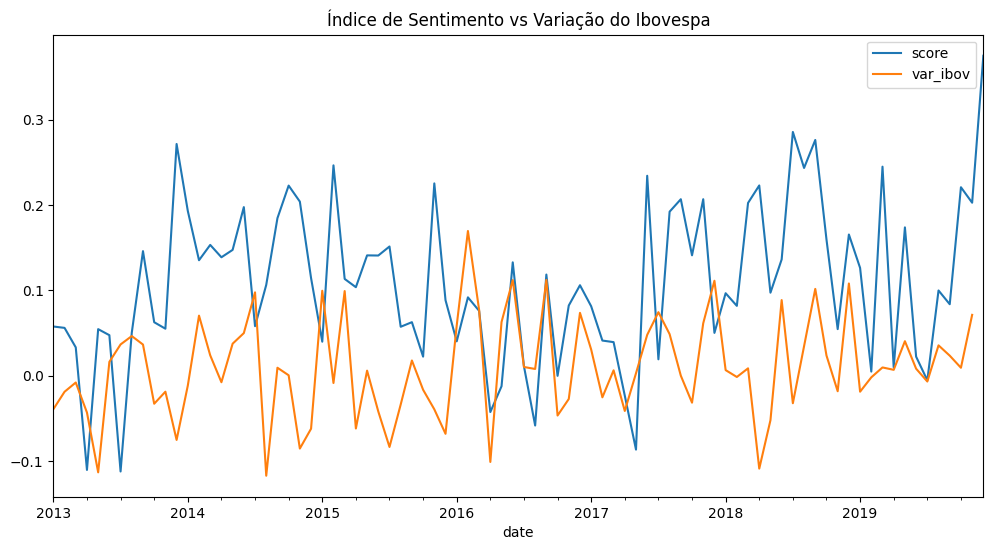

In [17]:
df_monthly_sentiment.plot(x='date', y=['score', 'var_ibov'], figsize=(12, 6), title='Índice de Sentimento vs Variação do Ibovespa')

## Aplicação de Z-Score para padronização dos dados

<Axes: title={'center': 'Índice de Sentimento vs Variação do Ibovespa (Padronizado)'}, xlabel='date'>

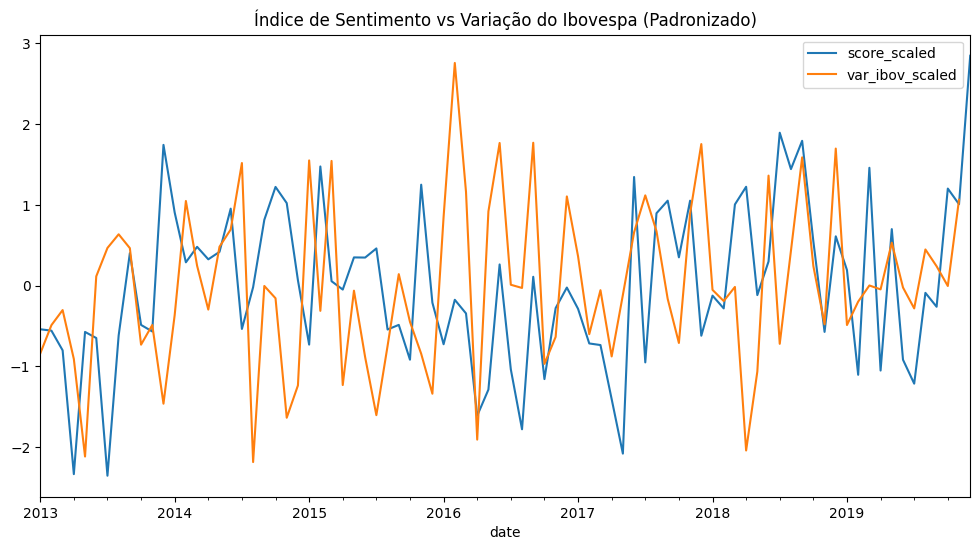

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_monthly_sentiment[['score', 'var_ibov']])
df_scaled = pd.DataFrame(df_scaled, columns=['score_scaled', 'var_ibov_scaled'])
df_scaled['date'] = df_monthly_sentiment['date']
df_scaled.plot(x='date', y=['score_scaled', 'var_ibov_scaled'], figsize=(12, 6), title='Índice de Sentimento vs Variação do Ibovespa (Padronizado)')